In [2]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay


In [3]:
#importing packages
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [4]:
#Load Dataset

red_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
white_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

red = pd.read_csv(red_url, sep=';')
white = pd.read_csv(white_url, sep=';')

red['type'] = 0
white['type'] = 1


In [5]:
# Merge datasets
df = pd.concat([red, white], axis=0).reset_index(drop=True)

print('Dataset shape:', df.shape)
print(df.head())

Dataset shape: (6497, 13)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  type  
0      9.4        5     0  
1   


Class distribution:
quality_label
0    5220
1    1277
Name: count, dtype: int64


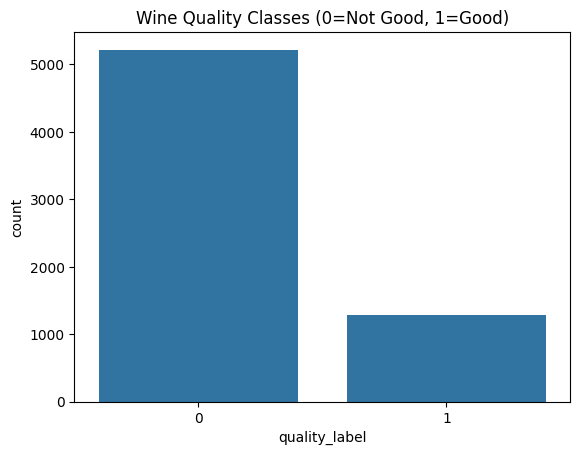

In [6]:
#Convert to Classification Problem
# Quality score ranges 3–9 Good Wine (>=7) vs Not Good (<7)

df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print('\nClass distribution:')
print(df['quality_label'].value_counts())

# Plot class distribution
plt.figure()
sns.countplot(x='quality_label', data=df)
plt.title('Wine Quality Classes (0=Not Good, 1=Good)')
plt.show()


In [7]:
#Train and Target Split

X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (5197, 12)
Test size: (1300, 12)


In [8]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# Gaussian Navie Bayes Model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
acc_nb =accuracy_score(y_test, y_pred)
print("Naive Bayes Accuracy:", acc_nb)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Naive Bayes Accuracy: 0.7346153846153847
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1044
           1       0.39      0.62      0.48       256

    accuracy                           0.73      1300
   macro avg       0.64      0.69      0.65      1300
weighted avg       0.79      0.73      0.75      1300

[[797 247]
 [ 98 158]]


In [16]:
#Logistic Regression
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
acc_lr = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", acc_lr)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Logistic Regression Accuracy: 0.8223076923076923
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1044
           1       0.61      0.26      0.37       256

    accuracy                           0.82      1300
   macro avg       0.73      0.61      0.63      1300
weighted avg       0.80      0.82      0.79      1300

[[1002   42]
 [ 189   67]]


In [17]:
#Desicion Tree
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
# Prediction
y_pred = model.predict(X_test)

# Evaluation
acc_dt = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", acc_dt)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Decision Tree Accuracy: 0.8315384615384616
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1044
           1       0.65      0.32      0.43       256

    accuracy                           0.83      1300
   macro avg       0.75      0.64      0.66      1300
weighted avg       0.81      0.83      0.81      1300

[[1000   44]
 [ 175   81]]


In [18]:
#KNN Classifier - Lazy Learner
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
acc_knn = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", acc_knn)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

KNN Accuracy: 0.8323076923076923
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1044
           1       0.59      0.48      0.53       256

    accuracy                           0.83      1300
   macro avg       0.73      0.70      0.71      1300
weighted avg       0.82      0.83      0.83      1300

[[960  84]
 [134 122]]


In [20]:
#Random Forest - Ensemble model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
acc_rf =accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Random Forest Accuracy: 0.8869230769230769
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1044
           1       0.80      0.57      0.66       256

    accuracy                           0.89      1300
   macro avg       0.85      0.77      0.80      1300
weighted avg       0.88      0.89      0.88      1300

[[1008   36]
 [ 111  145]]


In [21]:
#XGBoost
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
acc_xgb = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:",acc_xgb)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

XGBoost Accuracy: 0.8792307692307693
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1044
           1       0.73      0.62      0.67       256

    accuracy                           0.88      1300
   macro avg       0.82      0.78      0.80      1300
weighted avg       0.87      0.88      0.88      1300

[[985  59]
 [ 98 158]]


In [22]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest', 'XGBoost'],
    'Accuracy': [acc_nb, acc_lr, acc_dt, acc_knn, acc_rf, acc_xgb]
})

print(results)

                 Model  Accuracy
0          Naive Bayes  0.734615
1  Logistic Regression  0.822308
2        Decision Tree  0.831538
3                  KNN  0.832308
4        Random Forest  0.886923
5              XGBoost  0.879231


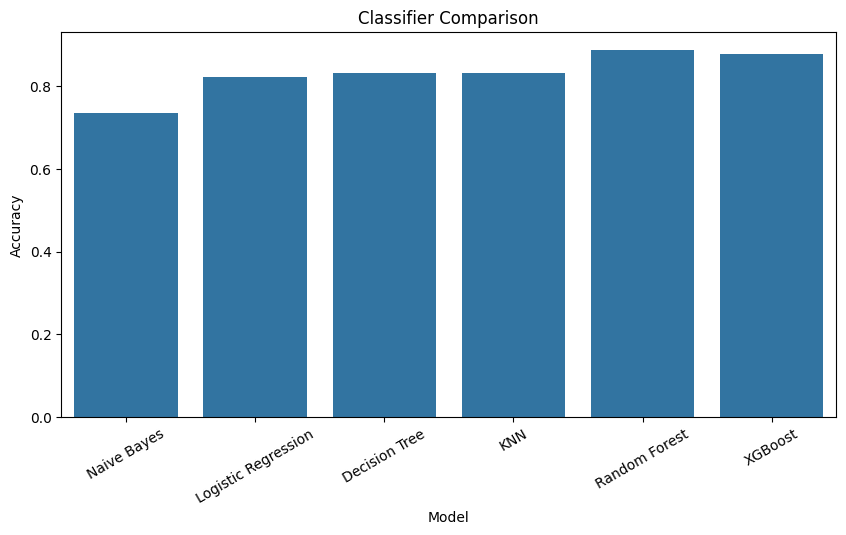

In [23]:
#Visualization
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.xticks(rotation=30)
plt.title("Classifier Comparison")
plt.show()